# Job Hunter Evaluation Notebook

This notebook evaluates the `job_hunter` agent which uses Adzuna for search, Jina for embeddings, and Gemini for job explanations.
The evaluation is performed by an OpenRouter LLM-as-judge on 5 mock profiles.


In [ ]:
# Install required dependencies
!pip install -q pydantic langchain-openai langchain-google-genai requests numpy matplotlib seaborn nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 13.5 MB/s eta 0:00:00


### 1. API Keys & LLM Setup


In [ ]:
import os
import time
import json
import re
import asyncio
import nest_asyncio
import requests
import numpy as np
from typing import Any, Optional, List, Dict, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import PydanticOutputParser

nest_asyncio.apply()

# --- API Keys ---
ADZUNA_APP_ID = os.getenv("ADZUNA_APP_ID", "")
ADZUNA_APP_KEY = os.getenv("ADZUNA_APP_KEY", "")
JINA_API_KEY = os.getenv("JINA_API_KEY", "")

GEMINI_API_KEYS = [
    "",
    "",
    "",
]
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")

def get_gemini_model(temperature=0.1, attempt=0):
    key = GEMINI_API_KEYS[attempt % len(GEMINI_API_KEYS)]
    return ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_api_key=key,
        temperature=temperature,
        max_retries=0,
        timeout=60.0,
    )

def get_openrouter_model(temperature=0.1):
    return ChatOpenAI(
        model="google/gemma-3-27b-it",
        api_key=OPENROUTER_API_KEY,
        base_url="https://openrouter.ai/api/v1",
        temperature=temperature,
        max_retries=0,
        timeout=60.0,
        default_headers={
            "HTTP-Referer": "https://careeratlas.app",
            "X-Title": "CareerAtlas Colab",
        }
    )

def retry_gemini(prompt: str, max_retries=3) -> str:
    last_exception = None
    for attempt in range(max_retries):
        try:
            model = get_gemini_model(attempt=attempt)
            res = model.invoke(prompt)
            return str(res.content)
        except Exception as e:
            last_exception = e
            print(f"Gemini API Error on attempt {attempt+1}: {e}")
            time.sleep(2)
    raise last_exception

def retry_openrouter(prompt_template, state_args, output_schema, max_retries=3):
    parser = PydanticOutputParser(pydantic_object=output_schema)
    fmt = parser.get_format_instructions()
    new_prompt = prompt_template + ("system", "CRITICAL OUTPUT FORMAT INSTRUCTIONS:\n{format_instructions}\nOutput ONLY valid JSON.")
    state_args["format_instructions"] = fmt
    last_exception = None
    for attempt in range(max_retries):
        try:
            model = get_openrouter_model()
            chain = new_prompt | model | parser
            return chain.invoke(state_args)
        except Exception as e:
            last_exception = e
            print(f"OpenRouter API Error on attempt {attempt+1}: {e}")
            time.sleep(2)
    raise last_exception


### 2. Schemas


In [ ]:
class ScoreBreakdown(BaseModel):
    semantic: float
    skill_overlap: float
    experience: float
    education: float
    final: float

class JobExplanation(BaseModel):
    strengths: List[str] = Field(default_factory=list)
    gaps: List[str] = Field(default_factory=list)
    reasoning: str = ""

class JobResult(BaseModel):
    job_id: str
    title: str
    company: Optional[str] = None
    location: Optional[str] = None
    apply_url: Optional[str] = None
    score: ScoreBreakdown
    explanation: JobExplanation
    remote: Optional[bool] = None
    match_pct: Optional[int] = None
    matched: List[str] = Field(default_factory=list)
    missing: List[str] = Field(default_factory=list)
    description: Optional[str] = None

class JobSearchResponse(BaseModel):
    query_role: str
    user_location_preference: str
    total_jobs_fetched: int
    jobs: List[JobResult]

class JudgeScore(BaseModel):
    criterion: Literal["role_relevance", "skill_alignment", "location_compliance", "explanation_quality"]
    score: int = Field(ge=1, le=5)
    rationale: str

class EvaluationVerdict(BaseModel):
    overall_score: float = Field(ge=1.0, le=5.0)
    pass_fail: Literal["pass", "fail"]
    rubric_scores: List[JudgeScore] = Field(default_factory=list)
    summary: str


### 3. Core Job Hunter Agent Logic


In [ ]:
INDIA_CITY_ALIASES = {
    "pune": {"pune", "poona"},
    "mumbai": {"mumbai", "bombay"},
    "bangalore": {"bangalore", "bengaluru"},
    "hyderabad": {"hyderabad", "hyd"},
    "delhi": {"delhi", "new delhi", "ncr", "gurugram", "noida", "gurgaon"},
    "chennai": {"chennai", "madras"},
}

FALLBACK_COMPANIES = ["Atlas Labs", "Northstar Systems", "Vector Harbor", "Summit Works", "Signal Foundry"]

def tokenize(text: str):
    return set(re.findall(r"[a-zA-Z0-9\+\#\.]+", (text or "").lower()))

def location_filter(job_loc: str, user_pref: str) -> bool:
    if not job_loc: return True
    job_loc_l = job_loc.lower()
    pref = (user_pref or "").lower().strip()
    if pref == "remote": return "remote" in job_loc_l
    if pref == "hybrid": return "hybrid" in job_loc_l or "remote" in job_loc_l
    aliases = INDIA_CITY_ALIASES.get(pref, {pref})
    return any(alias in job_loc_l for alias in aliases)

def fetch_jobs(query_role: str, where: str, results: int = 20) -> list[dict[str, Any]]:
    if ADZUNA_APP_ID == "YOUR_ADZUNA_APP_ID": return []
    url = "https://api.adzuna.com/v1/api/jobs/in/search/1"
    params = {
        "app_id": ADZUNA_APP_ID,
        "app_key": ADZUNA_APP_KEY,
        "what": query_role,
        "where": where if where not in {"remote", "hybrid"} else "",
        "results_per_page": results,
        "content-type": "application/json",
    }
    try:
        r = requests.get(url, params=params, timeout=25)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f"Adzuna fetch failed: {e}")
        return []
    jobs = []
    for j in data.get("results", []):
        jobs.append({
            "job_id": str(j.get("id")), "title": j.get("title"),
            "company": (j.get("company") or {}).get("display_name"),
            "location": (j.get("location") or {}).get("display_name"),
            "description": j.get("description") or "", "apply_url": j.get("redirect_url"),
        })
    return jobs

def _fallback_jobs(query_role: str, user_location_pref: str, count: int = 5) -> list[dict]:
    location = user_location_pref if user_location_pref else "Remote"
    titles = [f"{query_role}", f"Senior {query_role}", f"Mid-level {query_role}", f"Entry-level {query_role}", f"Contract {query_role}"]
    return [{
        "job_id": f"fallback-{idx + 1}", "title": titles[idx % len(titles)],
        "company": FALLBACK_COMPANIES[idx % len(FALLBACK_COMPANIES)],
        "location": location, "description": f'''Curated fallback listing for a {query_role} role in {location.lower()}.
        We are looking for someone with strong skills.''',
        "apply_url": "https://google.com"
    } for idx in range(count)]

def _fetch_jobs_with_fallback(query_role: str, user_location_pref: str, results: int = 20):
    search_variants = [query_role, f"{query_role} jobs", f"senior {query_role}"]
    where = query_role if user_location_pref.lower().strip() not in {"remote", "hybrid"} else ""
    for variant in search_variants:
        jobs = fetch_jobs(variant, where, results=results)
        if not jobs: continue
        strict = [j for j in jobs if location_filter(j.get("location") or "", user_location_pref)]
        if strict: return strict
        return jobs
    return _fallback_jobs(query_role, user_location_pref, count=min(results, 5))

def embed_batch(texts: list[str]) -> np.ndarray:
    if JINA_API_KEY == "YOUR_JINA_API_KEY":
        return np.random.rand(len(texts), 768).astype(np.float32)
    url = "https://api.jina.ai/v1/embeddings"
    headers = {"Authorization": f"Bearer {JINA_API_KEY}", "Content-Type": "application/json"}
    payload = {"model": "jina-embeddings-v2-base-en", "input": texts}
    r = requests.post(url, headers=headers, json=payload, timeout=30)
    r.raise_for_status()
    return np.array([d["embedding"] for d in r.json()["data"]], dtype=np.float32)

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

def score_jobs(resume: dict[str, Any], jobs: list[dict[str, Any]]):
    resume_text = " ".join((resume.get("skills") or []) + [resume.get("summary") or ""])
    job_texts = [f"{j.get('title') or ''} {j.get('description') or ''}".strip() for j in jobs]
    resume_skills = {s.lower() for s in resume.get("skills", []) if s.strip()}
    headline_tokens = tokenize(resume.get("headline", ""))

    try:
        embeds = embed_batch([resume_text] + job_texts)
        r_emb, j_embs = embeds[0], embeds[1:]
    except:
        r_emb, j_embs = None, None

    results = []
    for i, job in enumerate(jobs):
        overlap_tokens = resume_skills & tokenize(job_texts[i])
        skill_score = len(overlap_tokens) / max(len(resume_skills), 1)
        title_boost = 0.1 if any(tok in (job.get("title") or "").lower() for tok in headline_tokens if tok) else 0.0
        semantic = cosine_sim(r_emb, j_embs[i]) if r_emb is not None else min(1.0, 0.35 + 0.65 * skill_score)
        final = min(1.0, (0.55 * semantic + 0.25 * skill_score + 0.10 + 0.05 + 0.05 * title_boost))
        results.append({
            **job, "_matched_tokens": sorted(overlap_tokens)[:15],
            "_scores": {"semantic": semantic, "skill_overlap": skill_score, "experience": 1.0, "education": 1.0, "final": final}
        })
    return results

def safe_json_parse(text: str):
    text = re.sub(r"^```(?:json)?\s*", "", (text or "").strip(), flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text, flags=re.IGNORECASE)
    try:
        return json.loads(text.strip())
    except: return []

def job_finder_agent(resume: dict, target_role: str, user_location_pref: str, top_k: int = 5) -> JobSearchResponse:
    jobs = _fetch_jobs_with_fallback(target_role, user_location_pref, results=15)
    if not jobs: jobs = _fallback_jobs(target_role, user_location_pref, count=5)
    scored = sorted(score_jobs(resume, jobs), key=lambda x: x["_scores"]["final"], reverse=True)[:max(top_k, 7)]

    compact_jobs = [{"job_id": j.get("job_id"), "title": j.get("title"), "description": (j.get("description") or "")[:800]} for j in scored]
    prompt = f"""You are evaluating job fit for a candidate.
Return ONLY a valid JSON array — no markdown, no preamble.
Candidate skills: {resume.get('skills')}
Jobs to evaluate: {json.dumps(compact_jobs)}
For each job return:
[
  {{
    "job_id": "...",
    "strengths": ["specific skill or experience that matches"],
    "gaps": ["specific requirement missing from candidate profile"],
    "reasoning": "1-2 sentence overall fit summary"
  }}
]"""
    try:
        explanations_json = retry_gemini(prompt)
        explanations = {e.get("job_id"): e for e in safe_json_parse(explanations_json) if isinstance(e, dict)}
    except:
        explanations = {}

    out_jobs = []
    for j in scored[:top_k]:
        s, e = j["_scores"], explanations.get(j.get("job_id"), {"strengths": ["Match"], "gaps": [], "reasoning": "Fallback reasoning"})
        out_jobs.append(JobResult(
            job_id=str(j.get("job_id")),
            title=j.get("title") or "",
            company=j.get("company"),
            location=j.get("location"),
            score=ScoreBreakdown(**s),
            explanation=JobExplanation(**e),
            match_pct=int(round(s["final"] * 100)),
            matched=j.get("_matched_tokens", []),
            missing=e.get("gaps", []),
            description=j.get("description")
        ))
    return JobSearchResponse(query_role=target_role, user_location_preference=user_location_pref, total_jobs_fetched=len(jobs), jobs=out_jobs)


### 4. Evaluation Logic


In [ ]:
JUDGE_PROMPT = ChatPromptTemplate.from_template("""You are an evaluator of an AI Job Hunter agent.

TARGET ROLE: {target_role}
LOCATION PREFERENCE: {location}
CANDIDATE SKILLS: {skills}

AGENT RESPONSE:
{agent_response}

Score the agent's job matching 1-5 on each criterion (1=poor, 5=excellent):
1) role_relevance: Are the recommended job titles highly relevant to the target role?
2) skill_alignment: Do the matched keywords and job descriptions align with candidate skills?
3) location_compliance: Did it respect the user's location preference (or Remote/Hybrid)?
4) explanation_quality: Are the Gemini-generated strengths and gaps accurate and helpful?

PASS RULE: Pass if overall_score >= 3.0.
""")

def evaluate_jobs(target_role: str, location: str, resume: dict, response: JobSearchResponse) -> EvaluationVerdict:
    args = {
        "target_role": target_role,
        "location": location,
        "skills": ", ".join(resume.get("skills", [])),
        "agent_response": response.model_dump_json(indent=2),
    }
    return retry_openrouter(JUDGE_PROMPT, args, EvaluationVerdict)


### 5. Mock Profiles & Execution Loop


In [ ]:
print("Starting Job Hunter Evaluation...\n")

test_cases = [
    {"target_role": "Frontend Developer", "location": "Remote", "resume": {"headline": "Frontend Dev", "skills": ["React", "TypeScript", "Tailwind", "Next.js"], "summary": "Experienced UI developer."}},
    {"target_role": "Data Scientist", "location": "Bangalore", "resume": {"headline": "Data Scientist", "skills": ["Python", "SQL", "Machine Learning", "TensorFlow"], "summary": "ML specialist."}},
    {"target_role": "Product Manager", "location": "Hybrid", "resume": {"headline": "PM", "skills": ["Agile", "Scrum", "Jira", "Roadmapping"], "summary": "Certified scrum master and PM."}},
    {"target_role": "Backend Developer", "location": "Pune", "resume": {"headline": "Backend Engineer", "skills": ["Node.js", "AWS", "PostgreSQL", "Docker"], "summary": "Scalable backend architecture."}},
    {"target_role": "UI/UX Designer", "location": "Delhi", "resume": {"headline": "Designer", "skills": ["Figma", "Prototyping", "Wireframing", "User Research"], "summary": "User-centric design."}},
]

results = []
for idx, case in enumerate(test_cases):
    print(f"\n{'='*50}")
    print(f"Evaluating Profile {idx+1}: {case['target_role']} in {case['location']}")
    print(f"{'='*50}")
    try:
        res = job_finder_agent(case["resume"], case["target_role"], case["location"], top_k=3)
        print(f"Agent matched {len(res.jobs)} jobs.")
        for i, j in enumerate(res.jobs):
            print(f"  [Job {i+1}] {j.title} @ {j.company or 'Unknown'} (Match: {j.match_pct}%)")

        verdict = evaluate_jobs(case["target_role"], case["location"], case["resume"], res)
        results.append({"profile": case["target_role"], "score": verdict.overall_score})
        print(f"\n🤖 LLM Judge Score: {verdict.overall_score}/5.0 (Verdict: {verdict.pass_fail.upper()})")
        print(f"Summary: {verdict.summary}")

    except Exception as e:
        print(f"❌ Execution failed for profile {idx+1}: {e}")


Starting Job Hunter Evaluation...


Evaluating Profile 1: Frontend Developer in Remote
Agent matched 3 jobs.
  [Job 1] Frontend Developer @ InfoVision Inc. (Match: 66%)
  [Job 2] Frontend Developer @ Tata Consultancy Services (Match: 61%)
  [Job 3] Frontend Developer @ Tata Consultancy Services (Match: 61%)

🤖 LLM Judge Score: 2.75/5.0 (Verdict: FAIL)
Summary: The agent demonstrates good role relevance and reasonable explanation quality, but fails significantly on location compliance and skill alignment. It completely disregarded the remote location preference and didn't effectively prioritize or highlight the candidate's specified skills in the job matches. Therefore, the agent fails to meet the requirements.

Evaluating Profile 2: Data Scientist in Bangalore
Agent matched 3 jobs.
  [Job 1] Contract Data Scientist @ Signal Foundry (Match: 57%)
  [Job 2] Senior Data Scientist @ Northstar Systems (Match: 56%)
  [Job 3] Data Scientist @ Atlas Labs (Match: 56%)

🤖 LLM Judge Score: 3.5/5.0

### 6. Results Summary


/tmp/ipykernel_2659/1442171652.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="profile", y="score", palette="mako")


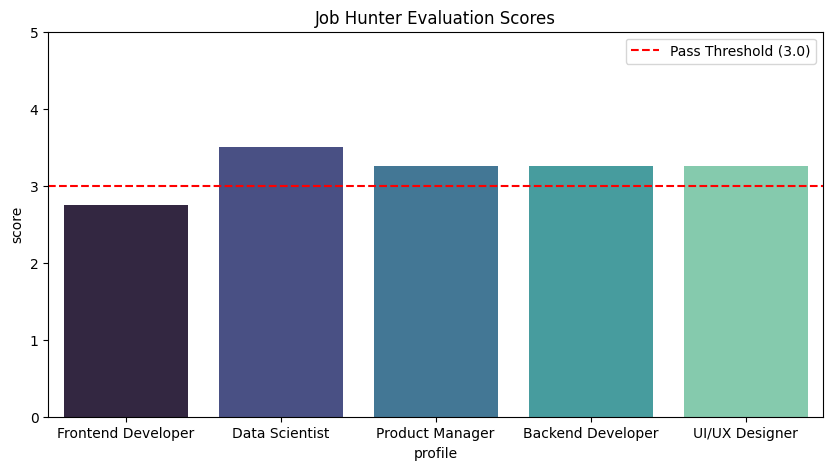

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if results:
    df = pd.DataFrame(results)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x="profile", y="score", palette="mako")
    plt.title("Job Hunter Evaluation Scores")
    plt.ylim(0, 5)
    plt.axhline(3.0, color="red", linestyle="--", label="Pass Threshold (3.0)")
    plt.legend()
    plt.show()
else:
    print("No results to plot.")
